In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [21]:
COLUMN_SNOW_2M = "snowfall (cm)"
COLUMN_DEW_2M = "snowfall (cm)"

In [22]:
df = pd.read_csv("herford_weather.csv", parse_dates=['time']).set_index('time')
display(df.index.dtype)
df[:5]

dtype('<M8[ns]')

,temperature_2m (°C),relativehumidity_2m (%),dewpoint_2m (°C),apparent_temperature (°C),pressure_msl (hPa),surface_pressure (hPa),precipitation (mm),rain (mm),snowfall (cm),weathercode (wmo code),...,et0_fao_evapotranspiration (mm),vapor_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
time,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-2.3,80,-5.3,-7.2,1003.4,988.2,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 01:00:00,-2.1,80,-5.2,-7.0,1003.8,988.6,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 02:00:00,-2.0,79,-5.2,-6.9,1003.9,988.7,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 03:00:00,-2.1,79,-5.3,-7.0,1004.0,988.8,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 04:00:00,-2.2,78,-5.5,-7.1,1004.5,989.3,0.0,0.0,0.0,3,...,0.01,0.12,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34


snowfall (cm)                        1.000000
weathercode (wmo code)               0.299132
precipitation (mm)                   0.177701
cloudcover_mid (%)                   0.151412
apparent_temperature (°C)            0.145608
temperature_2m (°C)                  0.142825
soil_temperature_7_to_28cm (°C)      0.137320
soil_temperature_0_to_7cm (°C)       0.137279
dewpoint_2m (°C)                     0.131738
soil_temperature_28_to_100cm (°C)    0.121669
Name: snowfall (cm), dtype: float64

<Axes: xlabel='snowfall (cm)', ylabel='None'>

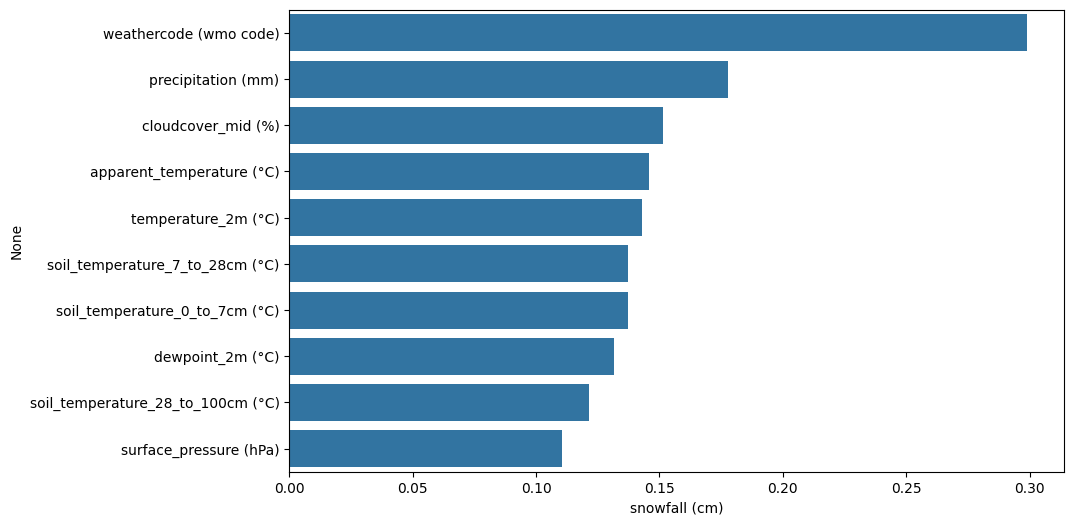

In [23]:
corr_matrix = df.corr()

# abs -> both pos and neg correlation should work
target_corr = corr_matrix[COLUMN_SNOW_2M].abs().sort_values(ascending=False)
display(target_corr[:10]) 

top_features = target_corr.index[1:11]  # [1: ] to remove self

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr[top_features], y=top_features)

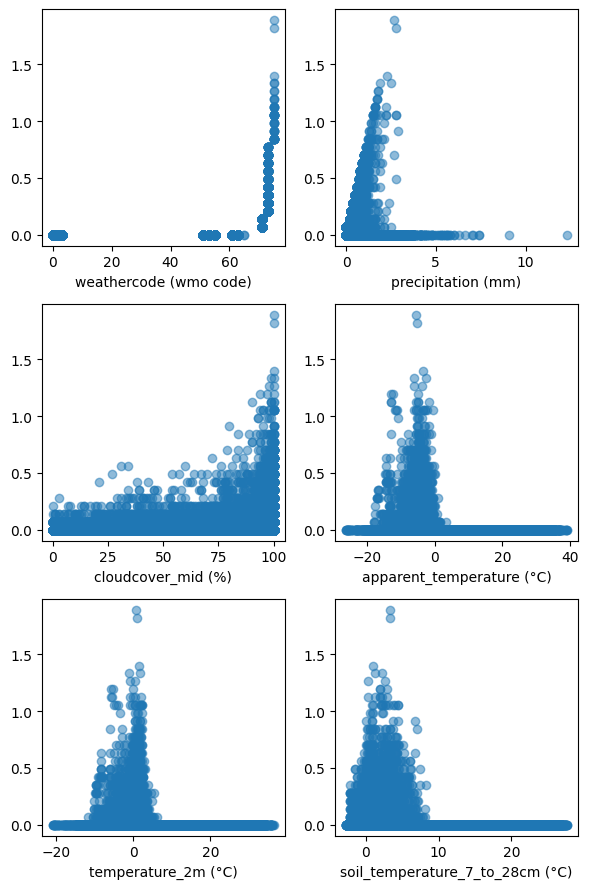

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i, feature in enumerate(target_corr.index[1:7]):
    axes.flat[i].scatter(df[feature], df[COLUMN_SNOW_2M], alpha=0.5)
    axes.flat[i].set_xlabel(feature)
plt.tight_layout()
plt.show()


Feature Importance (Random Forest):
weathercode (wmo code)             0.879497
precipitation (mm)                 0.081975
rain (mm)                          0.023425
soil_moisture_7_to_28cm (m³/m³)    0.002606
dewpoint_2m (°C)                   0.001896
temperature_2m (°C)                0.001670
winddirection_100m (°)             0.001384
winddirection_10m (°)              0.001272
apparent_temperature (°C)          0.000887
surface_pressure (hPa)             0.000546
dtype: float64


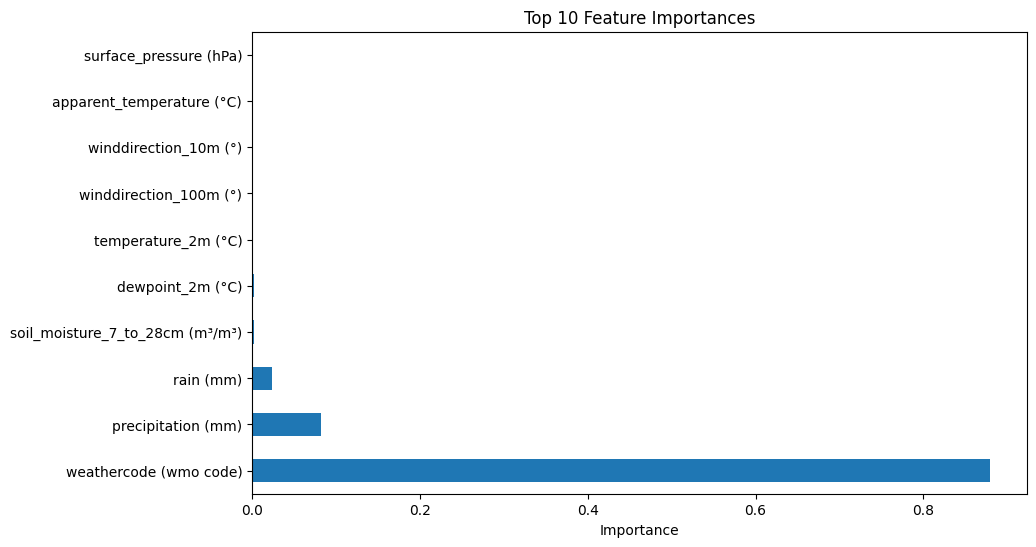

In [25]:
# Weitere Analyse: Feature Importance mit Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Daten vorbereiten (ohne NaN-Werte)
df_clean = df.dropna()
X = df_clean.drop(columns=[COLUMN_SNOW_2M])
y = df_clean[COLUMN_SNOW_2M]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modell
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance (Random Forest):")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_81452\1319634458.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='month', y=COLUMN_DEW_2M, color='b', ax=axs[0], ci=False)
C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_81452\1319634458.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='weekday', y=COLUMN_DEW_2M, color='r', ax=axs[1], ci=False)
C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_81452\1319634458.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='hour', y=COLUMN_DEW_2M, color='g', ax=axs[2], ci=False)


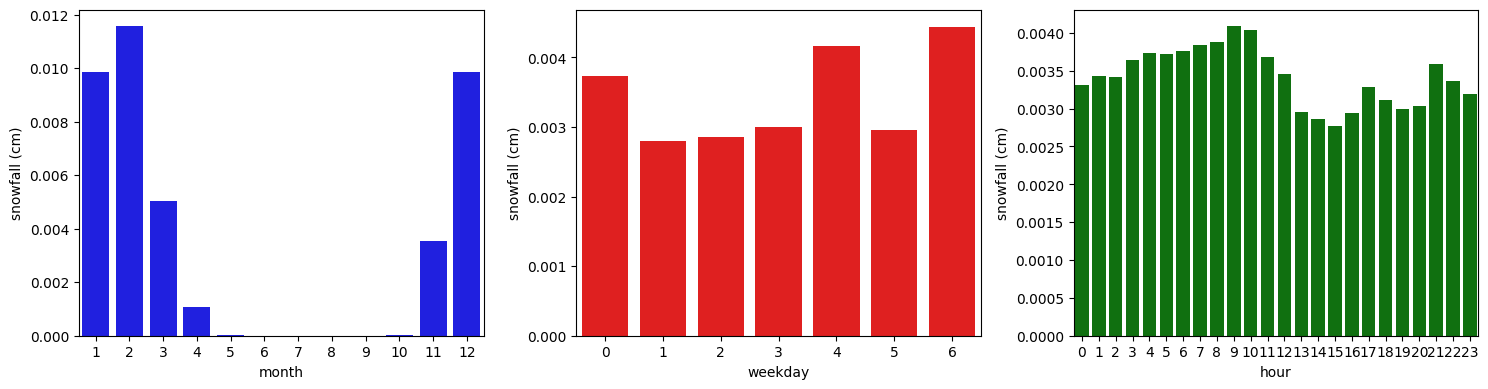

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

df['weekday'] = df.index.weekday
df['month'] = df.index.month
df['hour'] = df.index.hour
df[['weekday', 'month', 'hour']].head()

sns.barplot(data=df, x='month', y=COLUMN_DEW_2M, color='b', ax=axs[0], ci=False)
sns.barplot(data=df, x='weekday', y=COLUMN_DEW_2M, color='r', ax=axs[1], ci=False)
sns.barplot(data=df, x='hour', y=COLUMN_DEW_2M, color='g', ax=axs[2], ci=False)
plt.tight_layout()

In [31]:
train_attrib = [
    # "temperature_2m (°C)",
    # 'apparent_temperature (°C)',
    # "soil_temperature_0_to_7cm (°C)",
    # 'weathercode (wmo code)',
    "month",
    # "apparent_temperature (°C)",
    "temperature_2m (°C)",
    "soil_temperature_0_to_7cm (°C)",
    "soil_temperature_7_to_28cm (°C)",
    "weathercode (wmo code)",
    "precipitation (mm)",
    "cloudcover_mid (%)",
    "apparent_temperature (°C)"            
    

]


X = df[train_attrib].values # Trainingsdaten
y = df[[COLUMN_DEW_2M]].values #Targetvektor Arztkosten

scaler_X = StandardScaler() # Merkmalsskalierung mit Standardscaler
X = scaler_X.fit_transform(X)
scaler_y = StandardScaler() # Targetvektor wird auch skaliert
y = scaler_y.fit_transform(y)

x_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X, y, test_size=0.2, random_state=42)


X.shape, y.shape

((239570, 8), (239570, 1))

Epoch 1/5


c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2995/2995 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.0000e+00 - loss: 0.9454
Epoch 2/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.0000e+00 - loss: 0.9248
Epoch 3/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.0000e+00 - loss: 0.9245
Epoch 4/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.0000e+00 - loss: 0.9235
Epoch 5/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.9245
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 5s 902us/step
r2 = 0.104


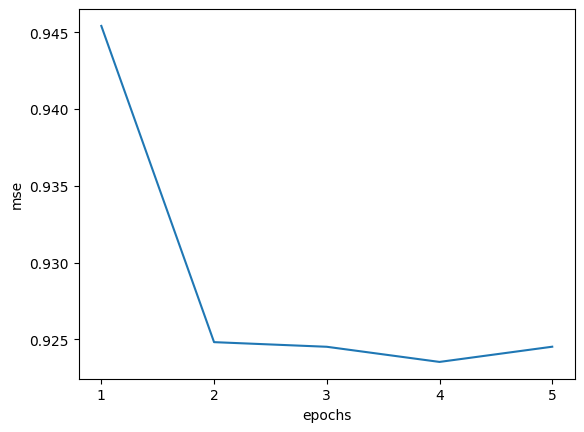

In [32]:
model = Sequential() # leeres Modellobjekt instanziieren
model.add(Dense(units=1, input_shape=(8,)))

model.compile(loss='mse', optimizer='sgd', metrics=['accuracy'])

history = model.fit(x_train_1, y_train_1, epochs=5, batch_size=64)

# Check model accuracy
y_pred = model.predict(x_train_1) # alle Targets mit trainiertem Modell rechnen
r2 = r2_score(y_train_1, y_pred) # R2 rechnen für Predictions und reale Targetvektoren
print('r2 = {:.3f}'.format(r2))


loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)